# Project Statement

The Film Junky Union, a new edgy community for classic movie enthusiasts, is developing a system for filtering and categorizing movie reviews. The goal is to train a model to automatically detect negative reviews. You'll be using a dataset of IMBD movie reviews with polarity labelling to build a model for classifying positive and negative reviews. It will need to have an F1 score of at least 0.85.

## Initialization

In [1]:
import math

import numpy as np
import pandas as pd

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import sklearn.metrics as metrics
from sklearn.dummy import DummyClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from lightgbm import LGBMClassifier
from lightgbm.callback import log_evaluation

import nltk
nltk.download('wordnet')
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
nltk.download('stopwords')
from nltk.corpus import stopwords as nltk_stopwords
from nltk.corpus import stopwords

import spacy

import torch
import transformers

from tqdm.auto import tqdm

import warnings
warnings.filterwarnings('ignore')

[nltk_data] Downloading package wordnet to /home/student/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /home/student/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'
# the next line provides graphs of better quality on HiDPI screens
%config InlineBackend.figure_format = 'retina'

plt.style.use('seaborn')

In [3]:
# this is to use progress_apply, read more at https://pypi.org/project/tqdm/#pandas-integration
tqdm.pandas()

## Load Data

In [4]:
df_reviews = pd.read_csv('/datasets/imdb_reviews.tsv', sep='\t', dtype={'votes': 'Int64'})

In [5]:
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47331 entries, 0 to 47330
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   tconst           47331 non-null  object 
 1   title_type       47331 non-null  object 
 2   primary_title    47331 non-null  object 
 3   original_title   47331 non-null  object 
 4   start_year       47331 non-null  int64  
 5   end_year         47331 non-null  object 
 6   runtime_minutes  47331 non-null  object 
 7   is_adult         47331 non-null  int64  
 8   genres           47331 non-null  object 
 9   average_rating   47329 non-null  float64
 10  votes            47329 non-null  Int64  
 11  review           47331 non-null  object 
 12  rating           47331 non-null  int64  
 13  sp               47331 non-null  object 
 14  pos              47331 non-null  int64  
 15  ds_part          47331 non-null  object 
 16  idx              47331 non-null  int64  
dtypes: Int64(1),

Data shows 47331 movie reviews, target concerns 'pos' column indicating either a positive (1) or negative review (0).

In [6]:
df_reviews.head(10)

,tconst,title_type,primary_title,original_title,start_year,end_year,runtime_minutes,is_adult,genres,average_rating,votes,review,rating,sp,pos,ds_part,idx
0,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,The pakage implies that Warren Beatty and Gold...,1,neg,0,train,8335
1,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,How the hell did they get this made?! Presenti...,1,neg,0,train,8336
2,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,There is no real story the film seems more lik...,3,neg,0,test,2489
3,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,Um .... a serious film about troubled teens in...,7,pos,1,test,9280
4,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,I'm totally agree with GarryJohal from Singapo...,9,pos,1,test,9281
5,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,This is the first movie I've seen from Singapo...,9,pos,1,test,9282
6,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,Yes non-Singaporean's can't see what's the big...,9,pos,1,test,9283
7,tt0035958,movie,'Gung Ho!': The Story of Carlson's Makin Islan...,'Gung Ho!': The Story of Carlson's Makin Islan...,1943,\N,88,0,"Drama,History,War",6.1,1240,This true story of Carlson's Raiders is more o...,2,neg,0,train,9903
8,tt0035958,movie,'Gung Ho!': The Story of Carlson's Makin Islan...,'Gung Ho!': The Story of Carlson's Makin Islan...,1943,\N,88,0,"Drama,History,War",6.1,1240,Should have been titled 'Balderdash!' Little i...,2,neg,0,train,9905
9,tt0035958,movie,'Gung Ho!': The Story of Carlson's Makin Islan...,'Gung Ho!': The Story of Carlson's Makin Islan...,1943,\N,88,0,"Drama,History,War",6.1,1240,The movie 'Gung Ho!': The Story of Carlson's M...,4,neg,0,train,9904


## EDA

Let's check the number of movies and reviews over years.

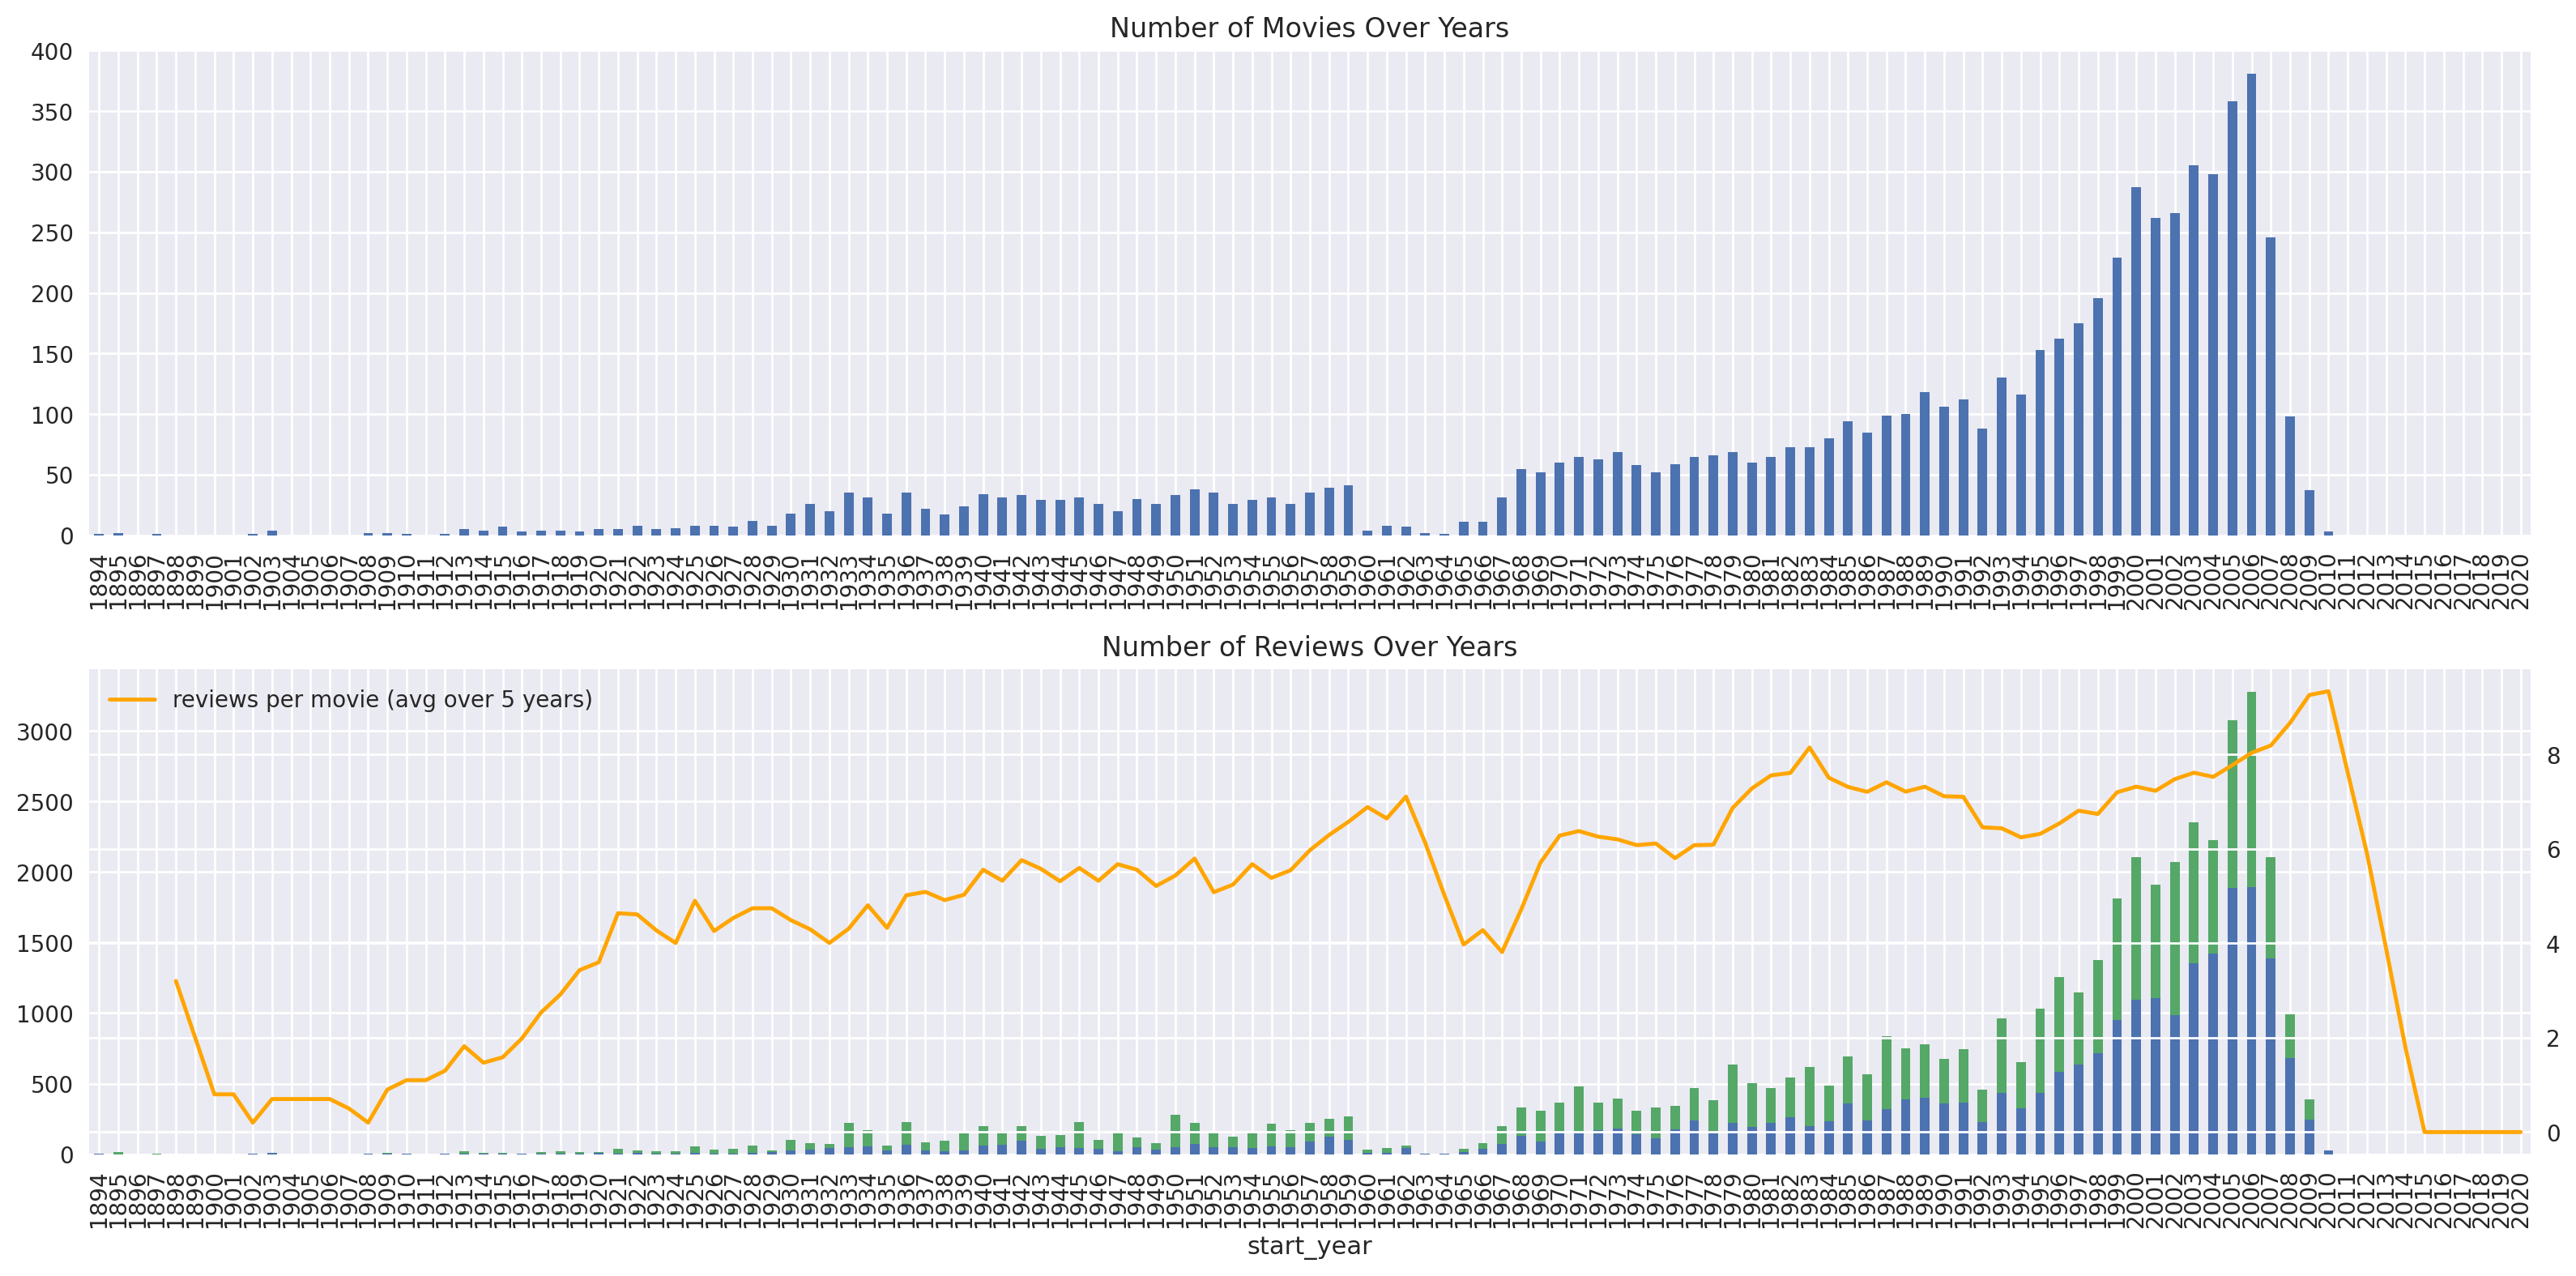

In [7]:
fig, axs = plt.subplots(2, 1, figsize=(16, 8))

ax = axs[0]

dft1 = df_reviews[['tconst', 'start_year']].drop_duplicates() \
    ['start_year'].value_counts().sort_index()
dft1 = dft1.reindex(index=np.arange(dft1.index.min(), max(dft1.index.max(), 2021))).fillna(0)
dft1.plot(kind='bar', ax=ax)
ax.set_title('Number of Movies Over Years')

ax = axs[1]

dft2 = df_reviews.groupby(['start_year', 'pos'])['pos'].count().unstack()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)

dft2.plot(kind='bar', stacked=True, label='#reviews (neg, pos)', ax=ax)

dft2 = df_reviews['start_year'].value_counts().sort_index()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)
dft3 = (dft2/dft1).fillna(0)
axt = ax.twinx()
dft3.reset_index(drop=True).rolling(5).mean().plot(color='orange', label='reviews per movie (avg over 5 years)', ax=axt)

lines, labels = axt.get_legend_handles_labels()
ax.legend(lines, labels, loc='upper left')

ax.set_title('Number of Reviews Over Years')

fig.tight_layout()

Movie review data spans from 1894 to 2020. Movie reviews appear to increase parallel to number of movies thorughout the years, reaching a maximum of over 3000 reviews on average per movie over a span of 5 years.  

Let's check the distribution of number of reviews per movie with the exact counting and KDE (just to learn how it may differ from the exact counting)

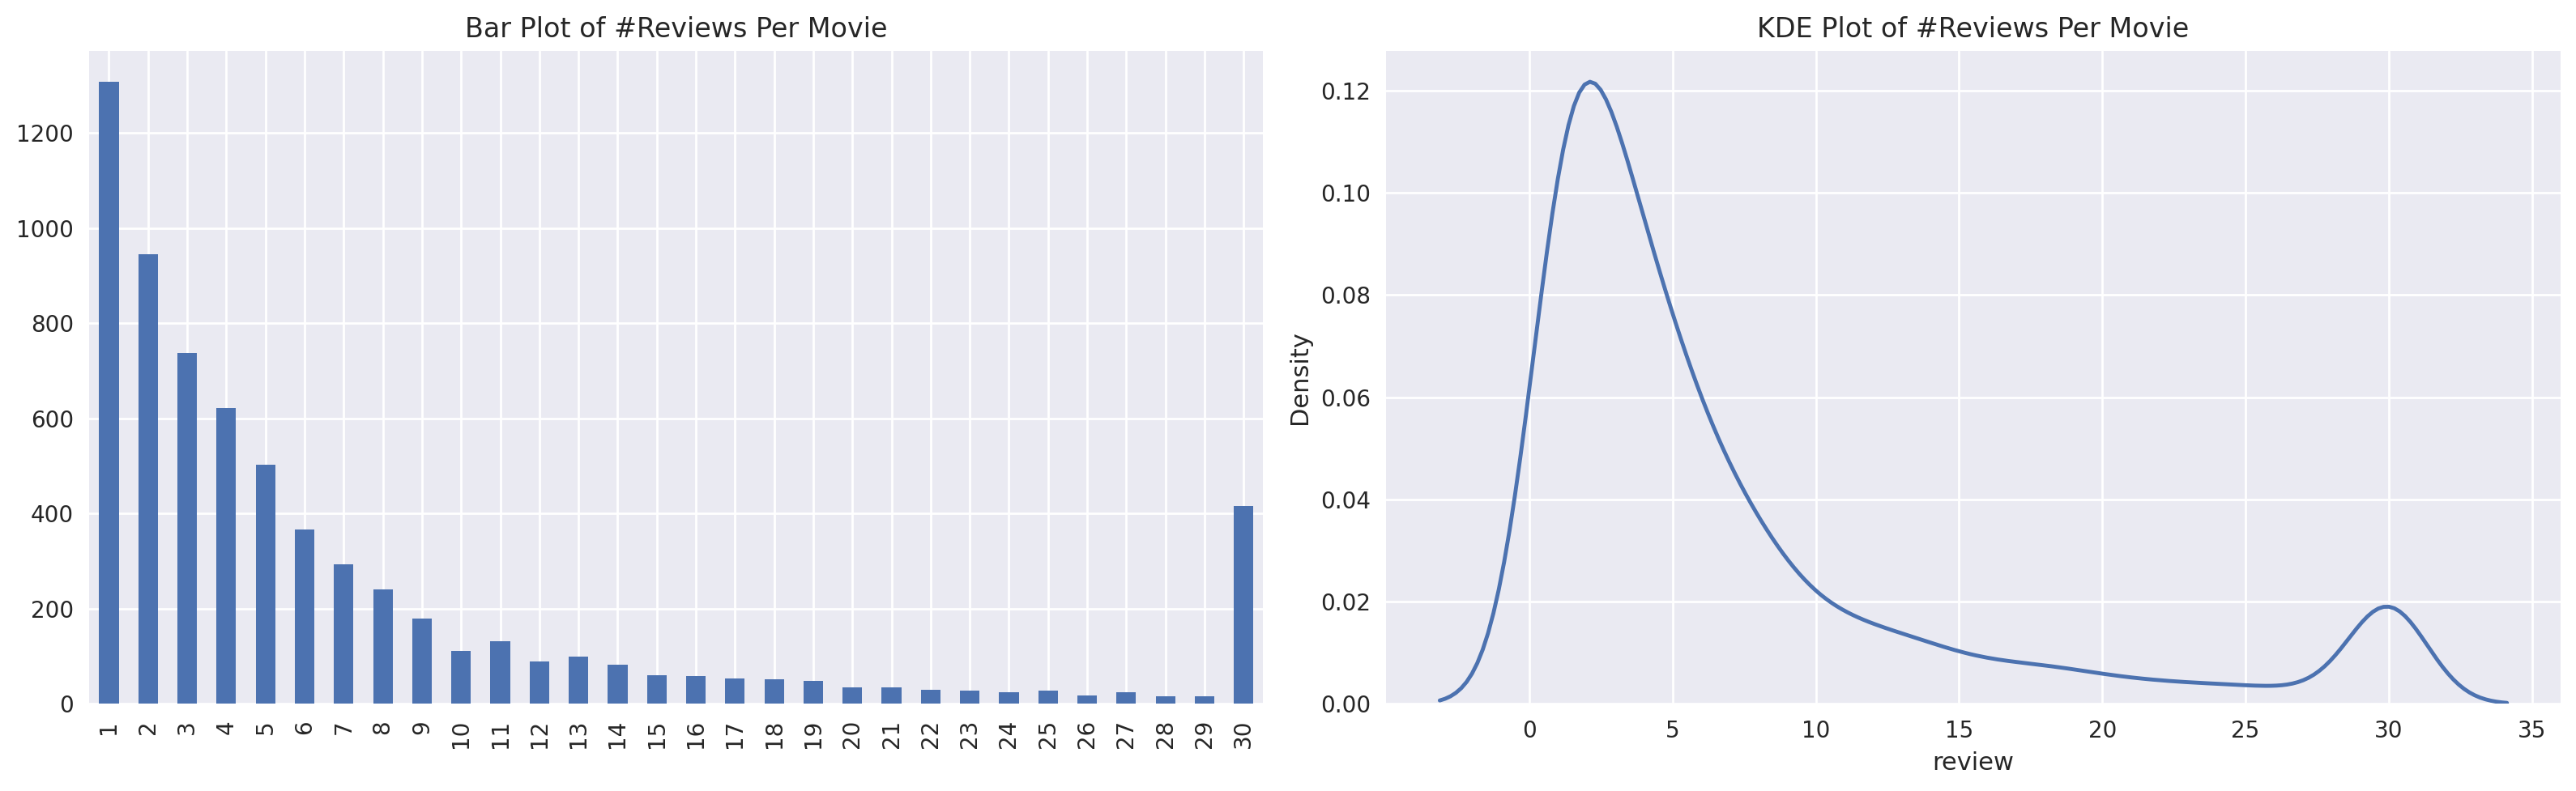

In [8]:
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

ax = axs[0]
dft = df_reviews.groupby('tconst')['review'].count() \
    .value_counts() \
    .sort_index()
dft.plot.bar(ax=ax)
ax.set_title('Bar Plot of #Reviews Per Movie')

ax = axs[1]
dft = df_reviews.groupby('tconst')['review'].count()
sns.kdeplot(dft, ax=ax)
ax.set_title('KDE Plot of #Reviews Per Movie')

fig.tight_layout()

Exact movie review count vs KDE plot shows reviews to potentialy have greater distribution compared to their exact counting. 

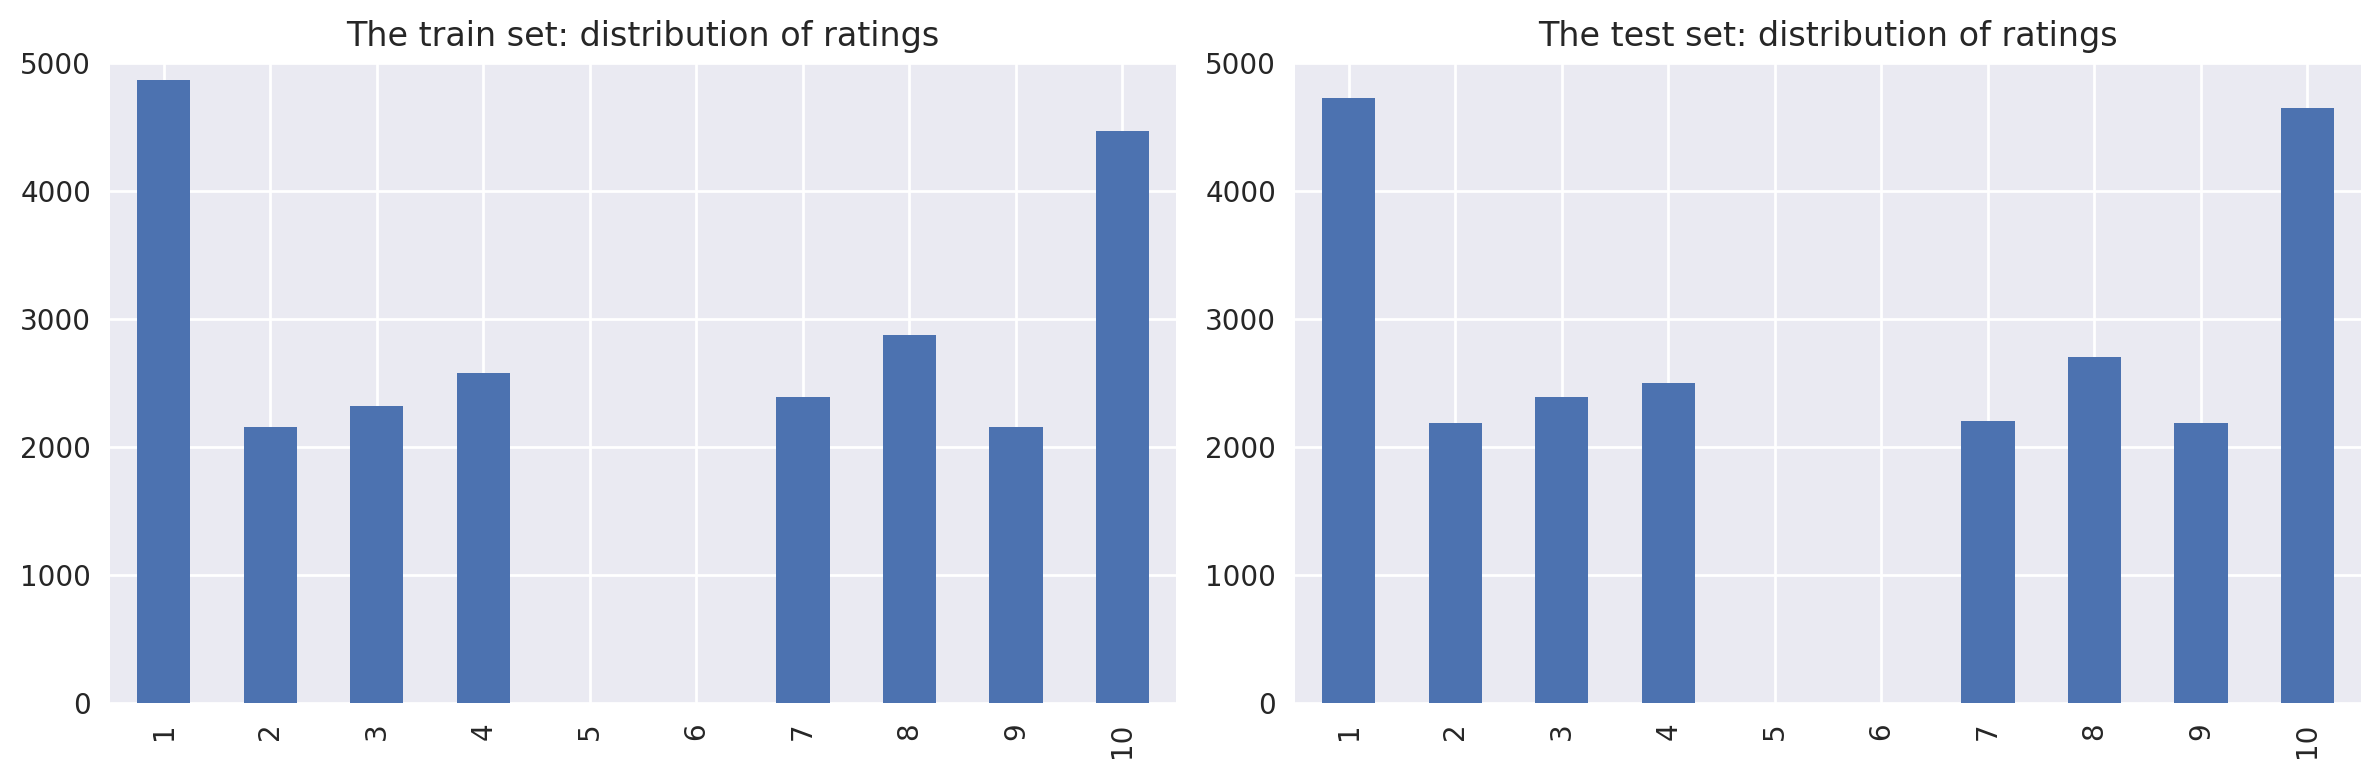

In [9]:
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

ax = axs[0]
dft = df_reviews.query('ds_part == "train"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('The train set: distribution of ratings')

ax = axs[1]
dft = df_reviews.query('ds_part == "test"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('The test set: distribution of ratings')

fig.tight_layout()

Comparision of train and test set regarding movie ratings, shows very similar distributions between sets. Ratings of either 1 or 10 being the highest in booth sets.

Distribution of negative and positive reviews over the years for two parts of the dataset

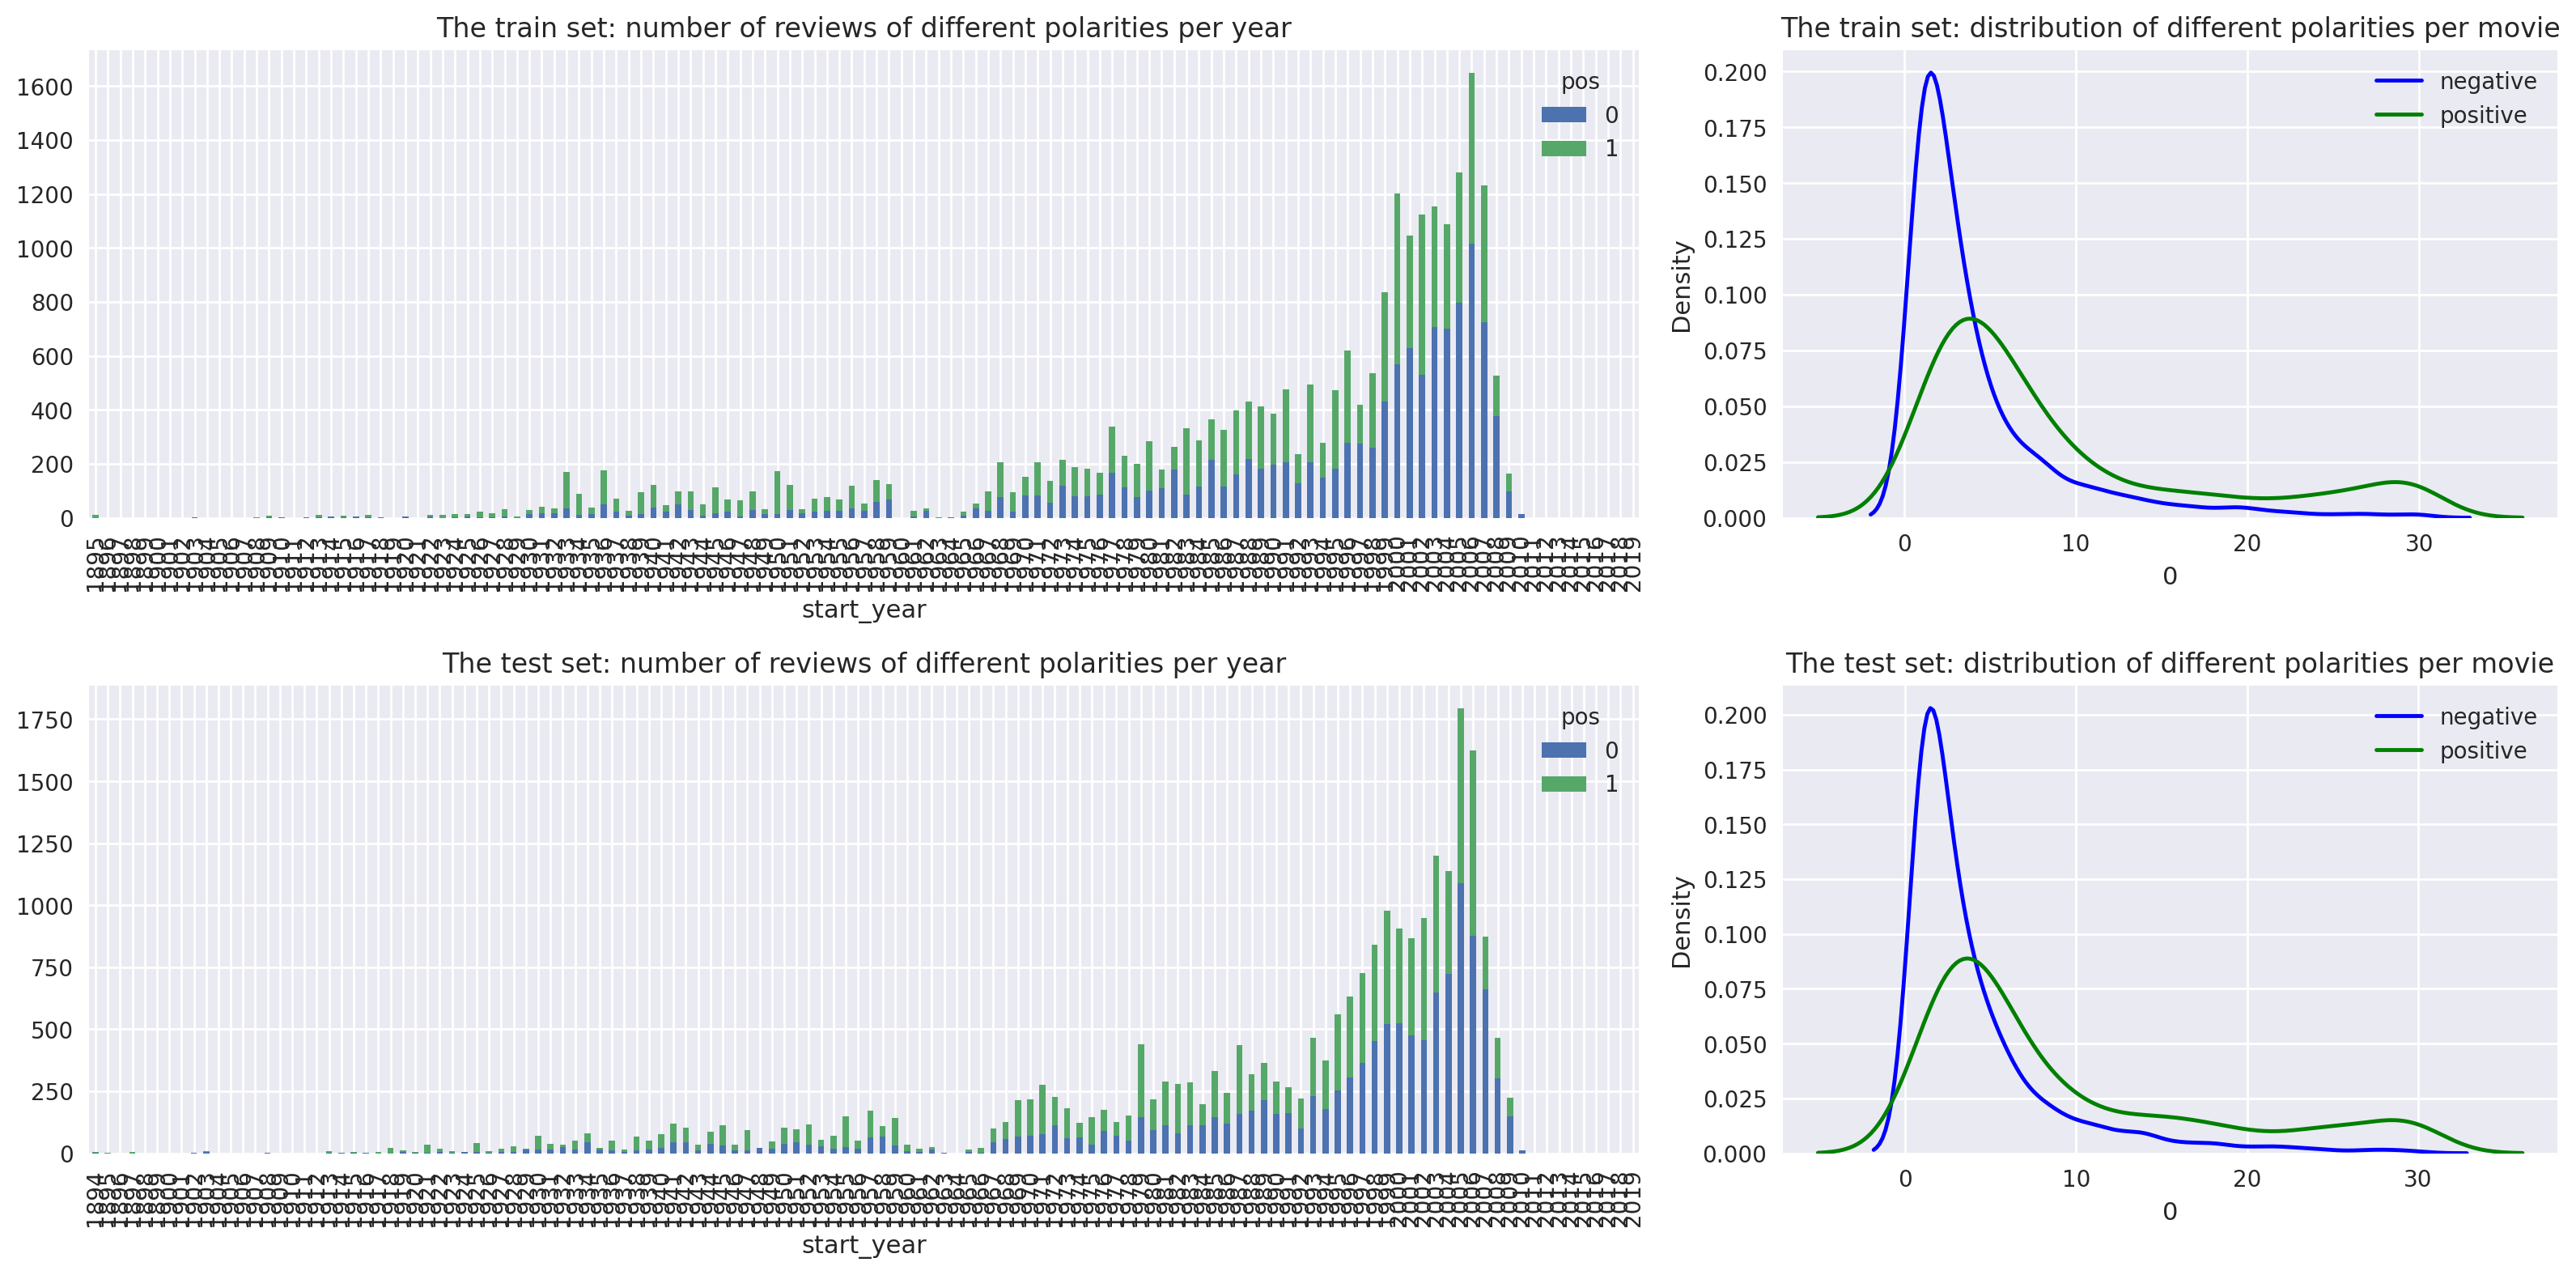

In [10]:
fig, axs = plt.subplots(2, 2, figsize=(16, 8), gridspec_kw=dict(width_ratios=(2, 1), height_ratios=(1, 1)))

ax = axs[0][0]

dft = df_reviews.query('ds_part == "train"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('The train set: number of reviews of different polarities per year')

ax = axs[0][1]

dft = df_reviews.query('ds_part == "train"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('The train set: distribution of different polarities per movie')

ax = axs[1][0]

dft = df_reviews.query('ds_part == "test"').groupby(['start_year', 'pos'])['pos'].count().unstack()
dft.index = dft.index.astype('int')
dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
dft.plot(kind='bar', stacked=True, ax=ax)
ax.set_title('The test set: number of reviews of different polarities per year')

ax = axs[1][1]

dft = df_reviews.query('ds_part == "test"').groupby(['tconst', 'pos'])['pos'].count().unstack()
sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
ax.legend()
ax.set_title('The test set: distribution of different polarities per movie')

fig.tight_layout()

Similarities across train and test sets can also be seen in thier polarity ratings throughout the years. Reviews across train and test sets appear to be more positive then negative, following similar patterns through the years. This indicates a good balance in across the sets which makes them viable for training and testing models.

## Evaluation Procedure

Composing an evaluation routine which can be used for all models in this project

In [11]:
def evaluate_model(model, train_features, train_target, test_features, test_target):
    
    eval_stats = {}
    
    fig, axs = plt.subplots(1, 3, figsize=(20, 6)) 
    
    for type, features, target in (('train', train_features, train_target), ('test', test_features, test_target)):
        
        eval_stats[type] = {}
    
        pred_target = model.predict(features)
        pred_proba = model.predict_proba(features)[:, 1]
        
        # F1
        f1_thresholds = np.arange(0, 1.01, 0.05)
        f1_scores = [metrics.f1_score(target, pred_proba>=threshold) for threshold in f1_thresholds]
        
        # ROC
        fpr, tpr, roc_thresholds = metrics.roc_curve(target, pred_proba)
        roc_auc = metrics.roc_auc_score(target, pred_proba)    
        eval_stats[type]['ROC AUC'] = roc_auc

        # PRC
        precision, recall, pr_thresholds = metrics.precision_recall_curve(target, pred_proba)
        aps = metrics.average_precision_score(target, pred_proba)
        eval_stats[type]['APS'] = aps
        
        if type == 'train':
            color = 'blue'
        else:
            color = 'green'

        # F1 Score
        ax = axs[0]
        max_f1_score_idx = np.argmax(f1_scores)
        ax.plot(f1_thresholds, f1_scores, color=color, label=f'{type}, max={f1_scores[max_f1_score_idx]:.2f} @ {f1_thresholds[max_f1_score_idx]:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(f1_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(f1_thresholds[closest_value_idx], f1_scores[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('threshold')
        ax.set_ylabel('F1')
        ax.legend(loc='lower center')
        ax.set_title(f'F1 Score') 

        # ROC
        ax = axs[1]    
        ax.plot(fpr, tpr, color=color, label=f'{type}, ROC AUC={roc_auc:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(roc_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'            
            ax.plot(fpr[closest_value_idx], tpr[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.plot([0, 1], [0, 1], color='grey', linestyle='--')
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('FPR')
        ax.set_ylabel('TPR')
        ax.legend(loc='lower center')        
        ax.set_title(f'ROC Curve')
        
        # PRC
        ax = axs[2]
        ax.plot(recall, precision, color=color, label=f'{type}, AP={aps:.2f}')
        # setting crosses for some thresholds
        for threshold in (0.2, 0.4, 0.5, 0.6, 0.8):
            closest_value_idx = np.argmin(np.abs(pr_thresholds-threshold))
            marker_color = 'orange' if threshold != 0.5 else 'red'
            ax.plot(recall[closest_value_idx], precision[closest_value_idx], color=marker_color, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02])    
        ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('recall')
        ax.set_ylabel('precision')
        ax.legend(loc='lower center')
        ax.set_title(f'PRC')        

        eval_stats[type]['Accuracy'] = metrics.accuracy_score(target, pred_target)
        eval_stats[type]['F1'] = metrics.f1_score(target, pred_target)
    
    df_eval_stats = pd.DataFrame(eval_stats)
    df_eval_stats = df_eval_stats.round(2)
    df_eval_stats = df_eval_stats.reindex(index=('Accuracy', 'F1', 'APS', 'ROC AUC'))
    
    print(df_eval_stats)
    
    return

## Normalization

We assume all models below accepts texts in lowercase and without any digits, punctuations marks etc.

In [12]:
df_reviews['review_norm'] = df_reviews['review'].str.lower()

## Train / Test Split

Luckily, the whole dataset is already divided into train/test one parts. The corresponding flag is 'ds_part'.

In [13]:
df_reviews_train = df_reviews.query('ds_part == "train"').copy()
df_reviews_test = df_reviews.query('ds_part == "test"').copy()

train_features = df_reviews_train['review_norm']
test_features = df_reviews_test['review_norm']

train_target = df_reviews_train['pos']
test_target = df_reviews_test['pos']

print(df_reviews_train.shape)
print(df_reviews_test.shape)

(23796, 18)
(23535, 18)


## Working with models

Text preprocessing will be done using nltk and spaCY for tokenization and lemmatization, TF-IDF will be used for vectorization. Training will be conductied using logistic Regression and LGBM classifier. BERT will be excluded due to processing time.

### Model 0 - Constant

In [14]:
dummy_clf = DummyClassifier(strategy='stratified')
dummy_clf.fit(train_features, train_target)

DummyClassifier(strategy='stratified')

In [15]:
dummy_pred = dummy_clf.predict(test_features)
dummy_score = dummy_clf.score(test_target, dummy_pred)

In [16]:
print(f"dummy constant score: {dummy_score:.2f}")

dummy constant score: 0.50


### Model 1 - NLTK, TF-IDF and LR

TF-IDF

In [17]:
# Tokenize and lemmatize text
def lemmatize_text(text):
    
    lemmatizer  = WordNetLemmatizer()

    processed_reviews = []
    for review in text:
        tokens = word_tokenize(review)
        lemmas = [lemmatizer.lemmatize(tok) for tok in tokens]
        processed_reviews.append(' '.join(lemmas))
        
    return processed_reviews

In [18]:
train_features_lem = lemmatize_text(train_features)
test_features_lem = lemmatize_text(test_features)

In [19]:
# Set stop words and initialize model instance
stop_words = nltk_stopwords.words('english')
count_tf_idf_nltk = TfidfVectorizer(stop_words=stop_words)

In [20]:
# Vectorize reviews
tf_idf_train_features = count_tf_idf_nltk.fit_transform(train_features_lem)
tf_idf_test_features = count_tf_idf_nltk.transform(test_features_lem)

In [21]:
# Initiate and train LR model
model_LR_nltk = LogisticRegression()
model_LR_nltk.fit(tf_idf_train_features, train_target)

LogisticRegression()

          train  test
Accuracy   0.94  0.88
F1         0.94  0.88
APS        0.98  0.95
ROC AUC    0.98  0.95


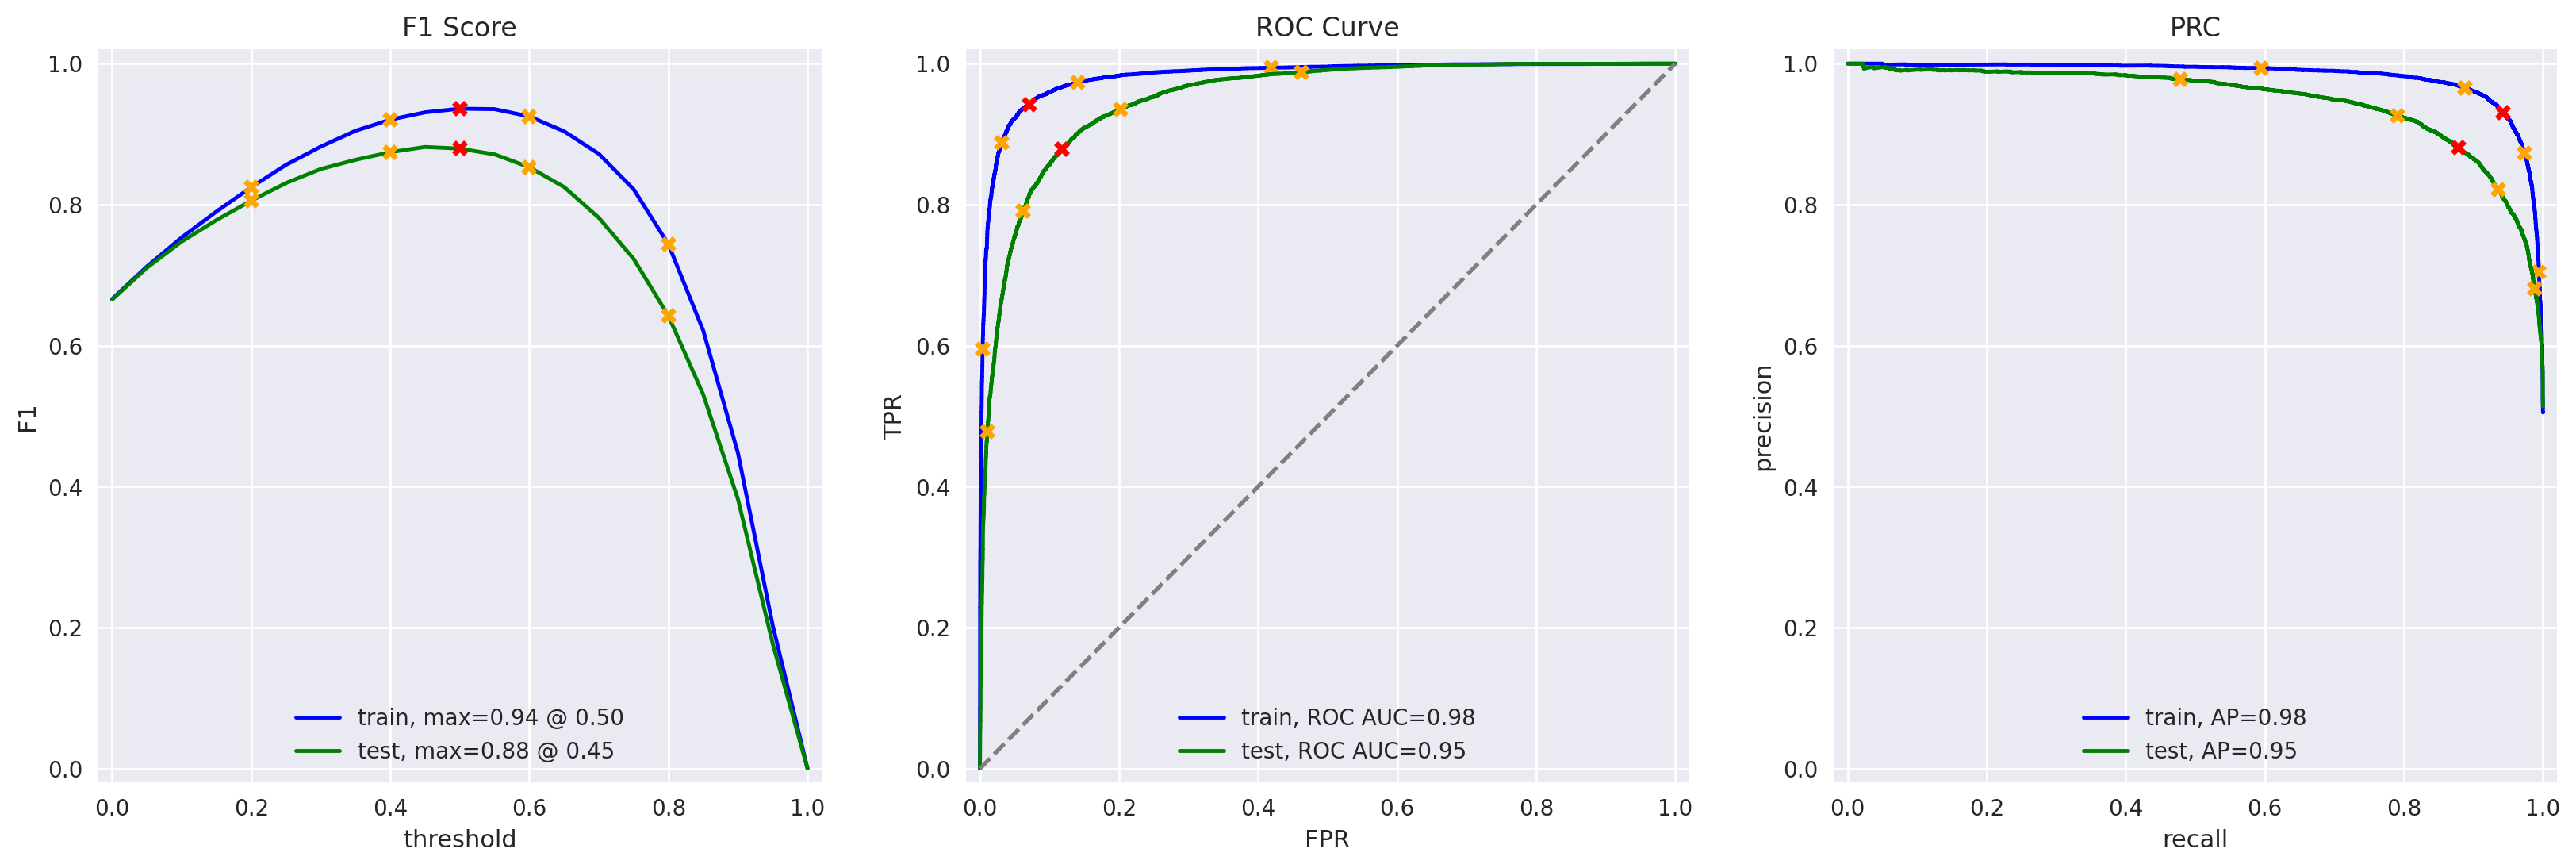

In [22]:
evaluate_nltk = evaluate_model(model_LR_nltk, tf_idf_train_features, train_target, tf_idf_test_features, test_target)

Preprocessing using nltk and TF-IDF with logistic regression achieves F1 score of 0.88 in test set. 

### Model 2 - spaCy, TF-IDF and LR

In [23]:
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

In [24]:
def text_preprocessing_3(text):

    review_lemmas = []
    for review in text:
        doc = nlp(review)
        lemmas = [token.lemma_ for token in doc if not token.is_stop]
        review_lemmas.append(' '.join(lemmas))
        
    return review_lemmas

In [25]:
train_features_spacy = text_preprocessing_3(train_features)
test_features_spacy = text_preprocessing_3(test_features)

In [26]:
count_tf_idf_spacy = TfidfVectorizer(stop_words=stop_words)

In [27]:
# Vectorize reviews
train_features_tfidf_spacy = count_tf_idf_spacy.fit_transform(train_features_spacy)
test_features_tfidf_spacy = count_tf_idf_spacy.transform(test_features_spacy)

In [28]:
# Initiate and train LR model
model_LR_spacy = LogisticRegression()
model_LR_spacy.fit(train_features_tfidf_spacy, train_target)

LogisticRegression()

          train  test
Accuracy   0.93  0.88
F1         0.93  0.88
APS        0.98  0.94
ROC AUC    0.98  0.95


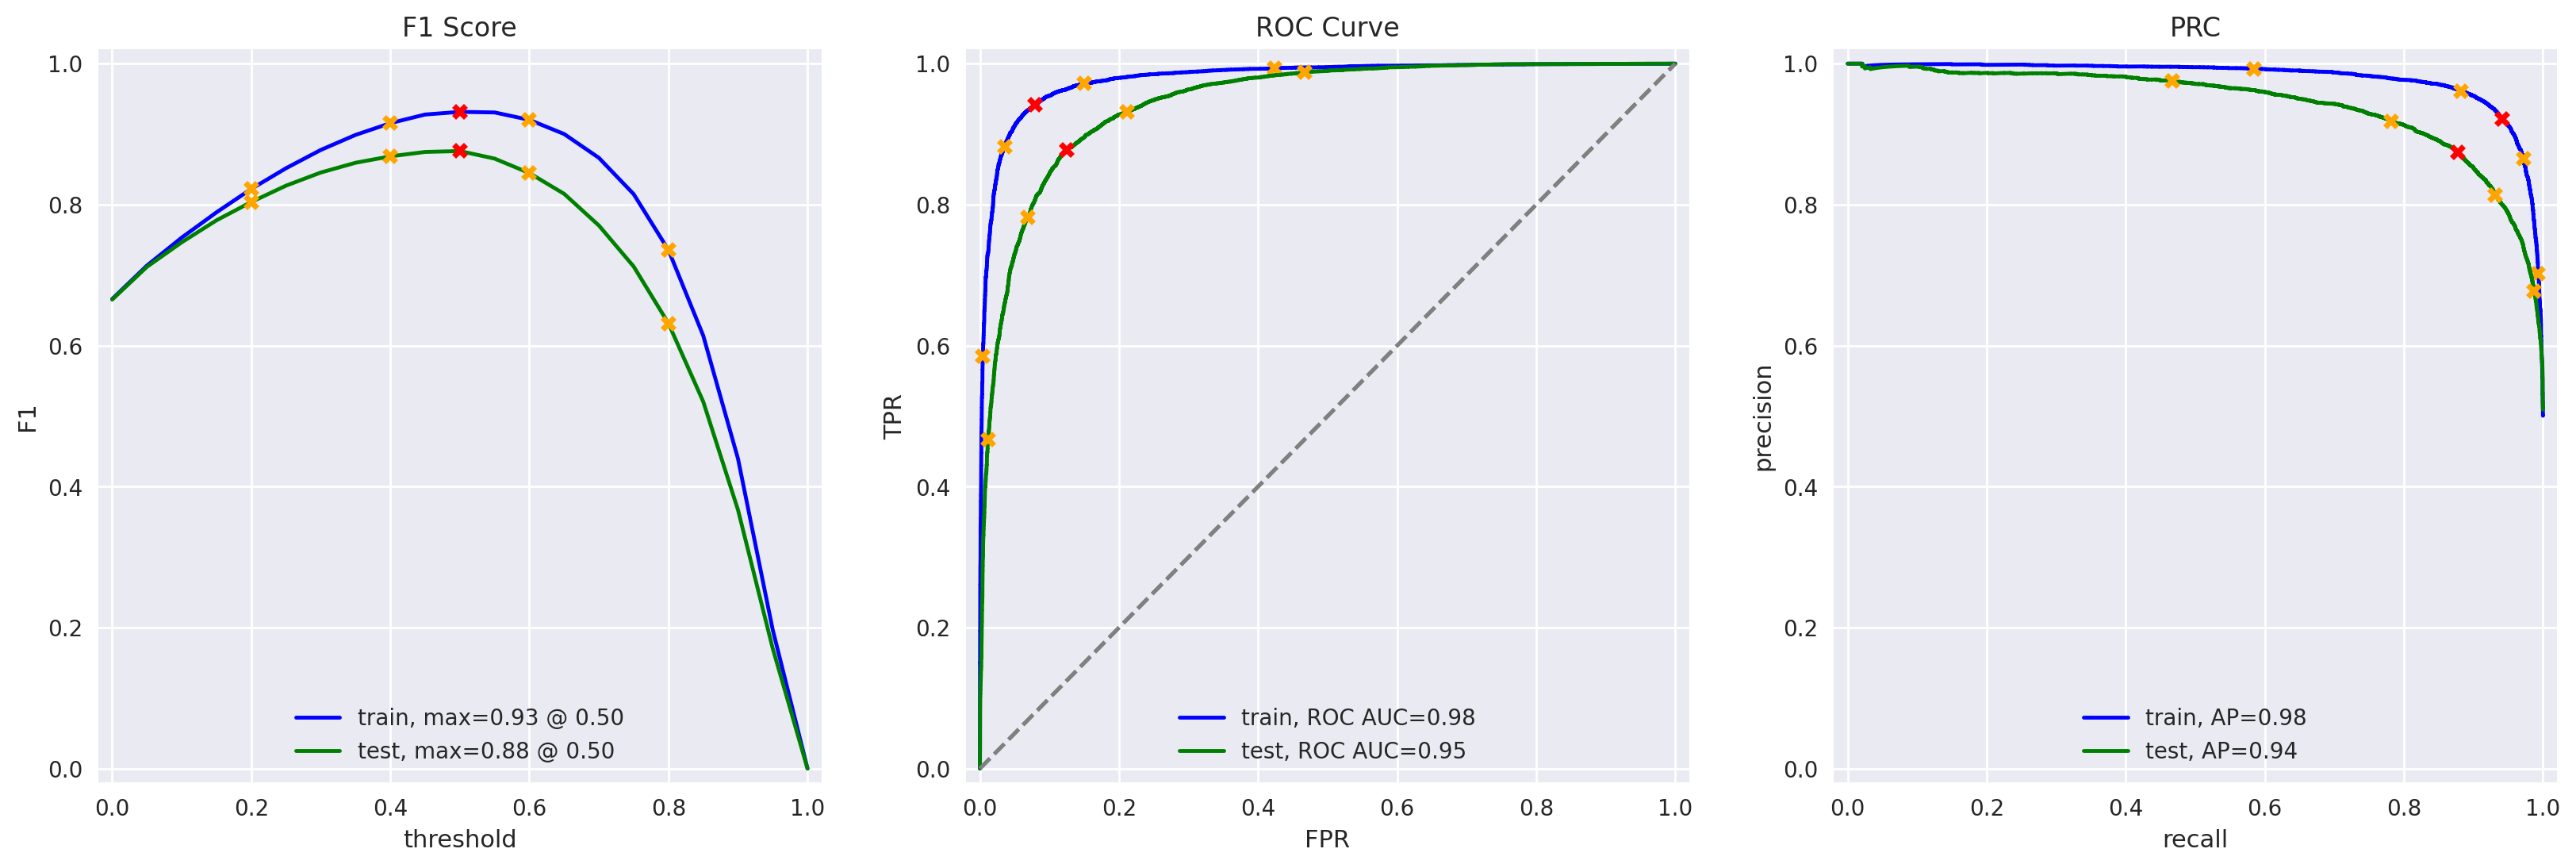

In [29]:
evaluate_spacy = evaluate_model(model_LR_spacy, train_features_tfidf_spacy, train_target, test_features_tfidf_spacy, test_target)

Preprocessing using spaCY and TF-IDF with logistic regression achieves F1 score of 0.88 in test set. 

### Model 3 - spaCy, TF-IDF and LGBMClassifier

In [30]:
model_LGBM = LGBMClassifier(random_state=12345, n_estimators=300)
model_LGBM.fit(train_features_tfidf_spacy, train_target, callbacks=[log_evaluation(period=0)])

LGBMClassifier(n_estimators=300, random_state=12345)

          train  test
Accuracy   0.98  0.86
F1         0.98  0.86
APS        1.00  0.94
ROC AUC    1.00  0.94


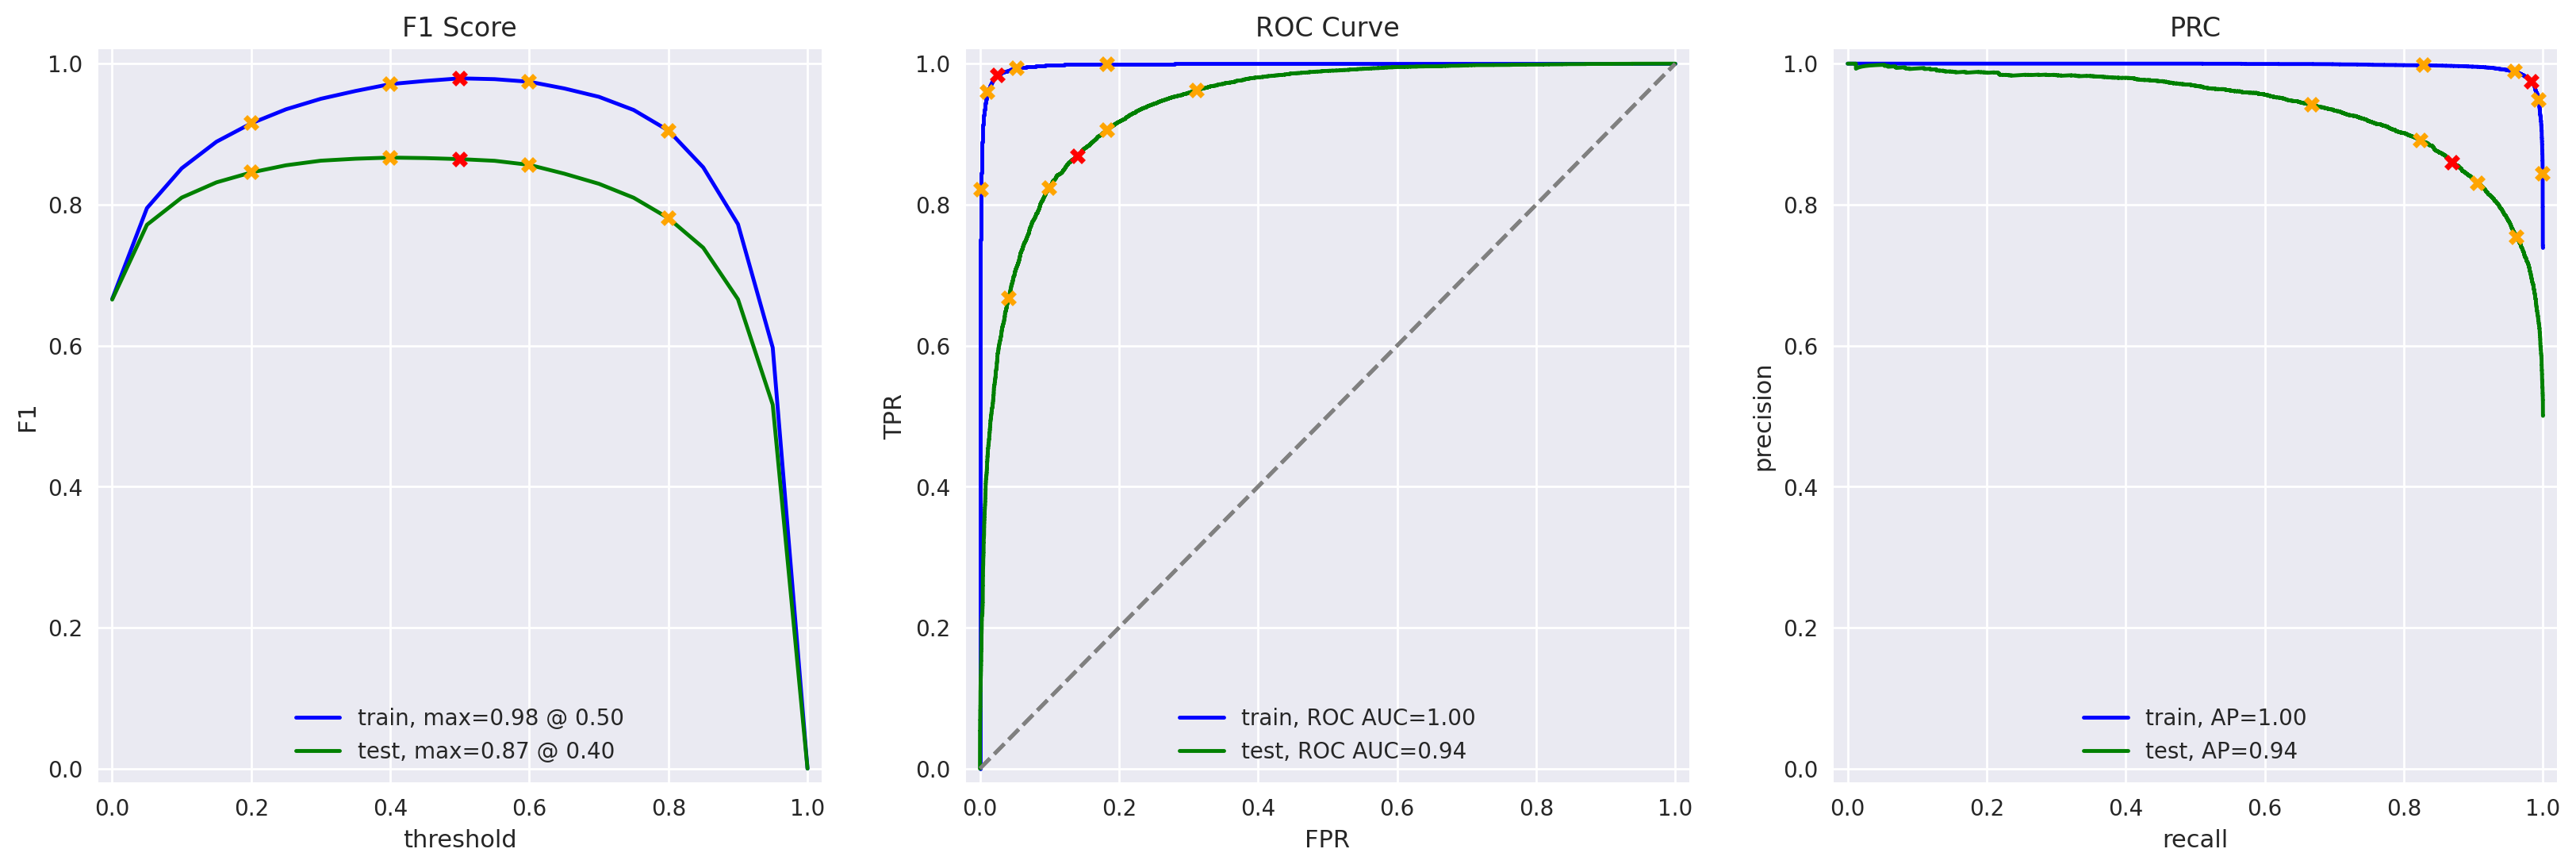

In [31]:
evaluate_LGBM = evaluate_model(model_LGBM, train_features_tfidf_spacy, train_target, test_features_tfidf_spacy, test_target)

Preprocessing using spaCY and TF-IDF with LGBM achieves F1 score of 0.86 in test set. Tuning might improve score. 

## My Reviews

Models will be tested directly to predict a small quantity of reviews to establish functionality and make comparisions. 

In [39]:
# feel free to completely remove these reviews and try your models on your own reviews, those below are just examples

my_reviews = pd.DataFrame([
    'I did not simply like it, not my kind of movie.',
    'Well, I was bored and felt asleep in the middle of the movie.',
    'I was really fascinated with the movie',    
    'Even the actors looked really old and disinterested, and they got paid to be in the movie. What a soulless cash grab.',
    'I didn\'t expect the reboot to be so good! Writers really cared about the source material',
    'The movie had its upsides and downsides, but I feel like overall it\'s a decent flick. I could see myself going to see it again.',
    'What a rotten attempt at a comedy. Not a single joke lands, everyone acts annoying and loud, even kids won\'t like this!',
    'Launching on Netflix was a brave move & I really appreciate being able to binge on episode after episode, of this exciting intelligent new drama.'
], columns=['review'])

my_reviews['review_norm'] = my_reviews['review'].str.lower()

my_reviews

,review,review_norm
0,"I did not simply like it, not my kind of movie.","i did not simply like it, not my kind of movie."
1,"Well, I was bored and felt asleep in the middl...","well, i was bored and felt asleep in the middl..."
2,I was really fascinated with the movie,i was really fascinated with the movie
3,Even the actors looked really old and disinter...,even the actors looked really old and disinter...
4,I didn't expect the reboot to be so good! Writ...,i didn't expect the reboot to be so good! writ...
5,"The movie had its upsides and downsides, but I...","the movie had its upsides and downsides, but i..."
6,What a rotten attempt at a comedy. Not a singl...,what a rotten attempt at a comedy. not a singl...
7,Launching on Netflix was a brave move & I real...,launching on netflix was a brave move & i real...


### Model 1 - NLTK, TF-IDF and LR 

In [40]:
texts = my_reviews['review_norm']

my_reviews_pred_prob_nltk = model_LR_nltk.predict_proba(count_tf_idf_nltk.transform(texts))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob_nltk[i]:.2f}:  {review}')

0.16:  i did not simply like it, not my kind of movie.
0.18:  well, i was bored and felt asleep in the middle of the movie.
0.57:  i was really fascinated with the movie
0.16:  even the actors looked really old and disinterested, and they got paid to be in the movie. what a so
0.39:  i didn't expect the reboot to be so good! writers really cared about the source material
0.48:  the movie had its upsides and downsides, but i feel like overall it's a decent flick. i could see my
0.11:  what a rotten attempt at a comedy. not a single joke lands, everyone acts annoying and loud, even ki
0.89:  launching on netflix was a brave move & i really appreciate being able to binge on episode after epi


Model using nltk appears to be functioning correctly and predicts sentiment probability appropriately.

### Model 2 - spaCy, TF-IDF and LR

In [41]:
texts = my_reviews['review_norm']
spacy_texts = text_preprocessing_3(texts)

my_reviews_pred_prob_spacy = model_LR_spacy.predict_proba(count_tf_idf_spacy.transform(spacy_texts))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob_spacy[i]:.2f}:  {review}')

0.16:  i did not simply like it, not my kind of movie.
0.08:  well, i was bored and felt asleep in the middle of the movie.
0.50:  i was really fascinated with the movie
0.18:  even the actors looked really old and disinterested, and they got paid to be in the movie. what a so
0.23:  i didn't expect the reboot to be so good! writers really cared about the source material
0.38:  the movie had its upsides and downsides, but i feel like overall it's a decent flick. i could see my
0.02:  what a rotten attempt at a comedy. not a single joke lands, everyone acts annoying and loud, even ki
0.90:  launching on netflix was a brave move & i really appreciate being able to binge on episode after epi


Predicting with spaCy preprocessing appears to function accordingly, some predictions could be seen as mislabled. Overall model appears to be working as intended.

### Model 3 - spaCy, TF-IDF and LGBMClassifier

In [42]:
texts = my_reviews['review_norm']


my_reviews_pred_prob_LGBM = model_LGBM.predict_proba(count_tf_idf_spacy.transform(spacy_texts))[:, 1]

for i, review in enumerate(texts.str.slice(0, 100)):
    print(f'{my_reviews_pred_prob_LGBM[i]:.2f}:  {review}')

0.52:  i did not simply like it, not my kind of movie.
0.16:  well, i was bored and felt asleep in the middle of the movie.
0.54:  i was really fascinated with the movie
0.21:  even the actors looked really old and disinterested, and they got paid to be in the movie. what a so
0.45:  i didn't expect the reboot to be so good! writers really cared about the source material
0.54:  the movie had its upsides and downsides, but i feel like overall it's a decent flick. i could see my
0.15:  what a rotten attempt at a comedy. not a single joke lands, everyone acts annoying and loud, even ki
0.89:  launching on netflix was a brave move & i really appreciate being able to binge on episode after epi


LGBM with spaCy appears to label reviews higher, this however to a smoother distribution between reviews that could better fit the task. 

## Conclusions

Project shows both logistic regression and LGBM models to be effective for sentiment analysis, with some key takeaways to note:
* Logistic regression with nlltk preprocessed text appears to perform better than other models.
* Functionality of models seems to be confirmed when comparing F1 score with review probabilities. As most models appear to predict low probabilities for either one or two reviews that could potentialy be positive. This corelates to the diferent models F1 score of around 0.80.
* Probaility prediction versus bipolar sentiment prediction, appears to be better suitied for classifiying movie reviews. This offers greater sentiment distribution not available in bipolar classification. In this case, one could argue model using LGBM from probability prediction is best model. However F1 score still puts logistic regression for bipolar classification higher.  